# Segmentación de Operaciones de Importación mediante Clustering
### Comercio exterior — Chile

**Objetivo del proyecto:** identificar segmentos naturales dentro de las operaciones de importación registradas, a partir de variables de magnitud (monto, peso, ticket promedio) y frecuencia de operación, para caracterizar distintos perfiles de comercio exterior.

**Enfoque:**
1. Preprocesamiento de variables numéricas (corrección de sesgo) y categóricas (codificación).
2. Selección del número de clusters (k) mediante Silhouette Score y método del codo.
3. Modelado con **K-Means** (`MiniBatchKMeans`), evaluando dos configuraciones: una línea base conservadora (k=2) y una versión de mayor granularidad (k=5).
4. Validación cruzada de la estabilidad de cada configuración.
5. Contraste con **K-Prototypes**, un algoritmo diseñado específicamente para datos mixtos (numéricos + categóricos), como validación independiente del resultado.
6. Caracterización de negocio de los clusters resultantes.

**Dataset:** ~1,57 millones de operaciones de importación, con variables de monto, cantidad, peso, rubro de la empresa, país de origen y vía de transporte.

In [1]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.cluster import MiniBatchKMeans
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import silhouette_score

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Carga de datos

In [2]:
df_import = pd.read_csv("./Data/Processed/processed_datos_chile_import.csv")

## 2. Selección de variables

Se excluyen del modelado `empresa` (alta cardinalidad — cientos de miles de valores únicos, lo que generaría una dimensionalidad excesiva vía one-hot encoding) y `descripcion_arancel` (texto libre, no categórico). Ambas se conservan en el dataset para el análisis de caracterización posterior, pero no participan en el cálculo de distancias del modelo.

In [3]:
#Quitamos "empresa" debido a su alta cardinalidad  y descrpción_arancel ya que , como dice su nombre; son solo descripcione. Se tomaran en cuenta solo para el análisis posterior
categorical_cols = ['rubro_empresa', 'pais', 'via_transporte']

In [4]:
numeric_cols = ['total_operacion',
 'cantidad_operacion',
 'ticket_promedio',
 'peso_total',
]

## 3. Preprocesamiento

- **Variables numéricas:** las variables de monto y peso presentan una distribución fuertemente sesgada (asimetría positiva, con una cola de operaciones de magnitud excepcional). Se aplica una transformación logarítmica (`log1p`) antes de estandarizar, para evitar que esos valores extremos dominen el cálculo de distancias de K-Means.
- **Variables categóricas:** se codifican con `OneHotEncoder`, ignorando categorías no vistas en entrenamiento (`handle_unknown="ignore"`).

In [5]:
log_pipeline = Pipeline([
    ("log", FunctionTransformer(np.log1p, validate=False)),
    ("scale", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            log_pipeline,
            numeric_cols
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            ),
            categorical_cols
        )
    ]
)

## 4. Pipeline de modelado

Se utiliza `MiniBatchKMeans` en lugar de `KMeans` estándar por razones de escalabilidad — con ~1,57M de filas, el ajuste por lotes (`batch_size=1024`) reduce significativamente el tiempo de cómputo sin una pérdida relevante de calidad.

In [6]:
pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("kmeans", MiniBatchKMeans(
        n_clusters=5,
        batch_size=1024,
        n_init=10,
        max_iter=100,
        random_state=42
    ))
])

## 5. Selección del número de clusters (k)

### 5.1 Silhouette Score

In [7]:
k_values = range(2, 10)

silhouette_scores = []

X = df_import[numeric_cols + categorical_cols]

X_transformed = preprocessor.fit_transform(X)

for k in k_values:

    pipeline.set_params(
        kmeans__n_clusters=k
    )

    labels = pipeline.named_steps["kmeans"].fit_predict(
        X_transformed
    )

    score = silhouette_score(
        X_transformed,
        labels,
        sample_size=10000,
        random_state=42
    )

    silhouette_scores.append(score)

    print(f"k={k}: silhouette={score:.4f}")

k=2: silhouette=0.2397
k=3: silhouette=0.1889
k=4: silhouette=0.1366
k=5: silhouette=0.1451
k=6: silhouette=0.1307
k=7: silhouette=0.1184
k=8: silhouette=0.1163
k=9: silhouette=0.1077


### 5.2 Método del codo (inercia)

In [8]:
k_values = range(2, 10)

inertia_scores = []

X = df_import[numeric_cols + categorical_cols]

X_transformed = preprocessor.fit_transform(X)

for k in k_values:

    pipeline.set_params(
        kmeans__n_clusters=k
    )

    pipeline.named_steps["kmeans"].fit(
        X_transformed
    )

    score = pipeline.named_steps["kmeans"].inertia_

    inertia_scores.append(score)

    print(f"k={k}: inertia={score:.2f}")

k=2: inertia=7098084.56
k=3: inertia=6198638.40
k=4: inertia=5693657.62
k=5: inertia=5268165.54
k=6: inertia=5078138.29
k=7: inertia=4953667.00
k=8: inertia=4806528.63
k=9: inertia=4590058.88


### 5.3 Visualización

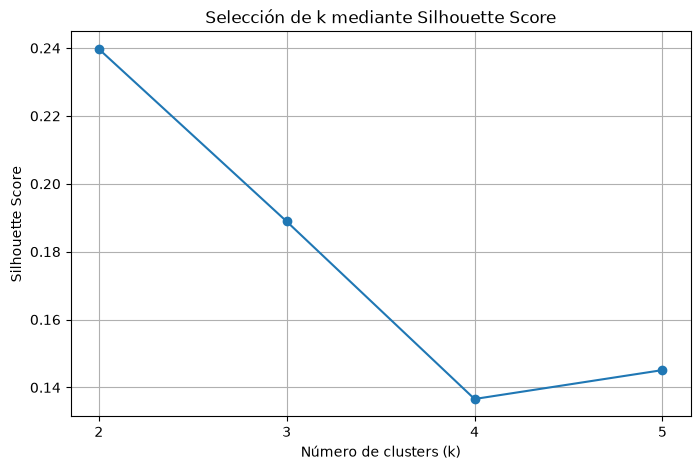

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    silhouette_scores,
    marker="o"
)

plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Selección de k mediante Silhouette Score")
plt.xticks(k_values)
plt.grid(True)

plt.show()

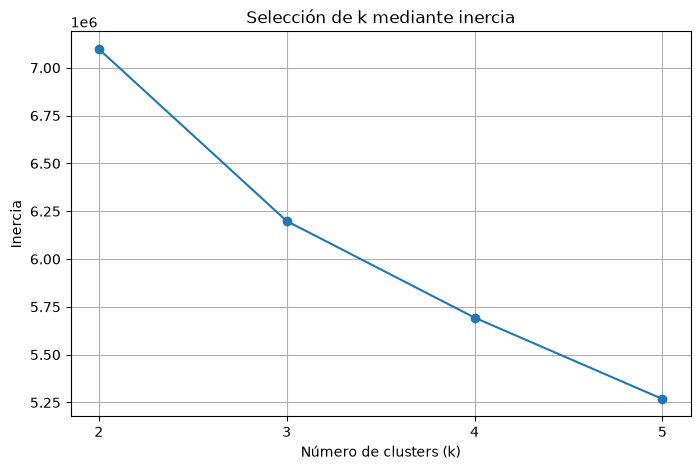

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    inertia_scores,
    marker="o"
)

plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.title("Selección de k mediante inercia")
plt.xticks(k_values)
plt.grid(True)

plt.show()

### 5.4 Interpretación

El silhouette score es más alto en **k=2 (0,2397)** y decrece de forma consistente a medida que se agregan más clusters. La inercia, por su parte, decrece de forma continua sin un quiebre ("codo") claramente marcado, por lo que no aporta una señal adicional decisiva.

En términos puramente estadísticos, k=2 es la opción mejor soportada por ambas métricas. Sin embargo, una segmentación en solo 2 grupos (esencialmente "operaciones grandes" vs. "operaciones pequeñas") tiene poco valor práctico para caracterizar el negocio. Por eso, este notebook desarrolla **dos modelos en paralelo**:

- **Modelo A (k=2):** línea base estadísticamente óptima, usada como referencia de separación máxima alcanzable.
- **Modelo B (k=5):** una segmentación más granular, aceptando una pérdida de silhouette a cambio de mayor interpretabilidad de negocio — evaluada explícitamente antes de adoptarla como resultado principal.

## 6. Modelo A — k=2 (línea base)

In [11]:
k=2

### 6.1 Validación cruzada

In [12]:
from sklearn.model_selection import KFold

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

#k = 3

scores = []

X = df_import[numeric_cols + categorical_cols]

for train_idx, val_idx in kf.split(X):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    X_train_transformed = preprocessor.fit_transform(X_train)
    X_val_transformed = preprocessor.transform(X_val)

    kmeans = MiniBatchKMeans(
        n_clusters=k,
        random_state=42,
        batch_size=1024,
        n_init=3,
        max_iter=50
    )

    kmeans.fit(X_train_transformed)

    val_labels = kmeans.predict(X_val_transformed)

    # Solo una muestra para calcular silhouette
    sample_size = min(10000, X_val_transformed.shape[0])

    rng = np.random.RandomState(42)
    indices = rng.choice(
        X_val_transformed.shape[0],
        size=sample_size,
        replace=False
    )

    score = silhouette_score(
        X_val_transformed[indices],
        val_labels[indices]
    )

    scores.append(score)

    print(f"Fold terminado: silhouette={score:.4f}")

print("\nSilhouette por fold:")
print(scores)

print("\nMedia:")
print(np.mean(scores))

print("\nDesviación estándar:")
print(np.std(scores))

Fold terminado: silhouette=0.2354
Fold terminado: silhouette=0.2354
Fold terminado: silhouette=0.2361
Fold terminado: silhouette=0.2337
Fold terminado: silhouette=0.2361

Silhouette por fold:
[0.2354197654134361, 0.23543454085633939, 0.23609465743992358, 0.23370667416963734, 0.23606643640091735]

Media:
0.23534441485605076

Desviación estándar:
0.0008695026169331433


In [13]:
resultados_cv = pd.DataFrame({
    "fold": range(1, len(scores) + 1),
    "silhouette": scores
})

resultados_cv.loc["media"] = ["media", np.mean(scores)]
resultados_cv.loc["std"] = ["std", np.std(scores)]

resultados_cv

,fold,silhouette
0,1,0.235420
1,2,0.235435
2,3,0.236095
3,4,0.233707
4,5,0.236066
media,media,0.235344
std,std,0.000870


### 6.2 Entrenamiento del modelo final

In [14]:
pipeline.set_params(
    kmeans__n_clusters=k
)

pipeline.fit(
    df_import[numeric_cols + categorical_cols]
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('kmeans', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['total_operacion','cantidad_operacion','ticket_promedio',..., 'rubro_empresa','pais','via_transporte']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automati

### 6.3 Perfil de los clusters

In [15]:
df_import["cluster"] = pipeline.predict(
    df_import[numeric_cols + categorical_cols]
)

In [16]:
df_import["cluster"].value_counts().sort_index()

cluster
0    792668
1    779354
Name: count, dtype: int64

In [17]:
pd.options.display.float_format = '{:,.2f}'.format

df_import.groupby("cluster")[numeric_cols].mean().T

cluster,0,1
total_operacion,"430,322.45","5,555.58"
cantidad_operacion,15.07,2.19
ticket_promedio,"72,413.75","3,348.05"
peso_total,"559,579.31","3,957.02"


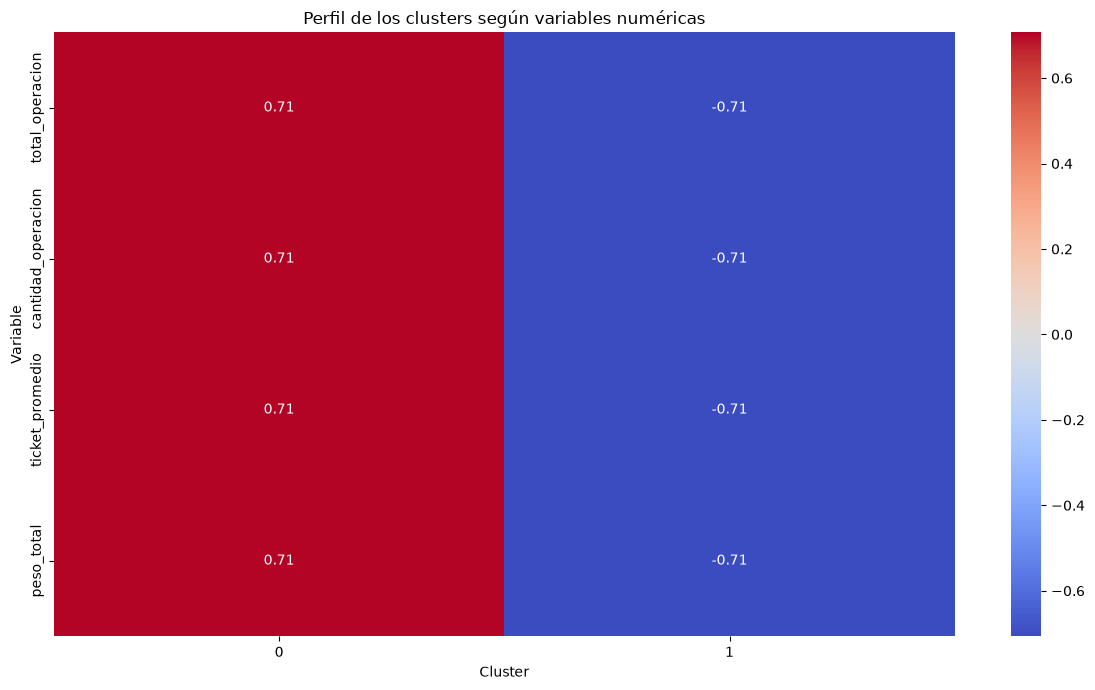

In [18]:
cluster_medias = df_import.groupby("cluster")[numeric_cols].mean()

cluster_medias_norm = (
    cluster_medias - cluster_medias.mean()
) / cluster_medias.std()

plt.figure(figsize=(12, 7))

sns.heatmap(
    cluster_medias_norm.T,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.xlabel("Cluster")
plt.ylabel("Variable")
plt.title("Perfil de los clusters según variables numéricas")
plt.tight_layout()
plt.show()

In [19]:
pd.options.display.float_format = '{:,.2f}'.format

df_import.groupby("cluster")[numeric_cols].median().T

cluster,0,1
total_operacion,"71,548.86","2,788.03"
cantidad_operacion,5.00,1.00
ticket_promedio,"17,039.97","1,458.31"
peso_total,"37,333.19",538.00


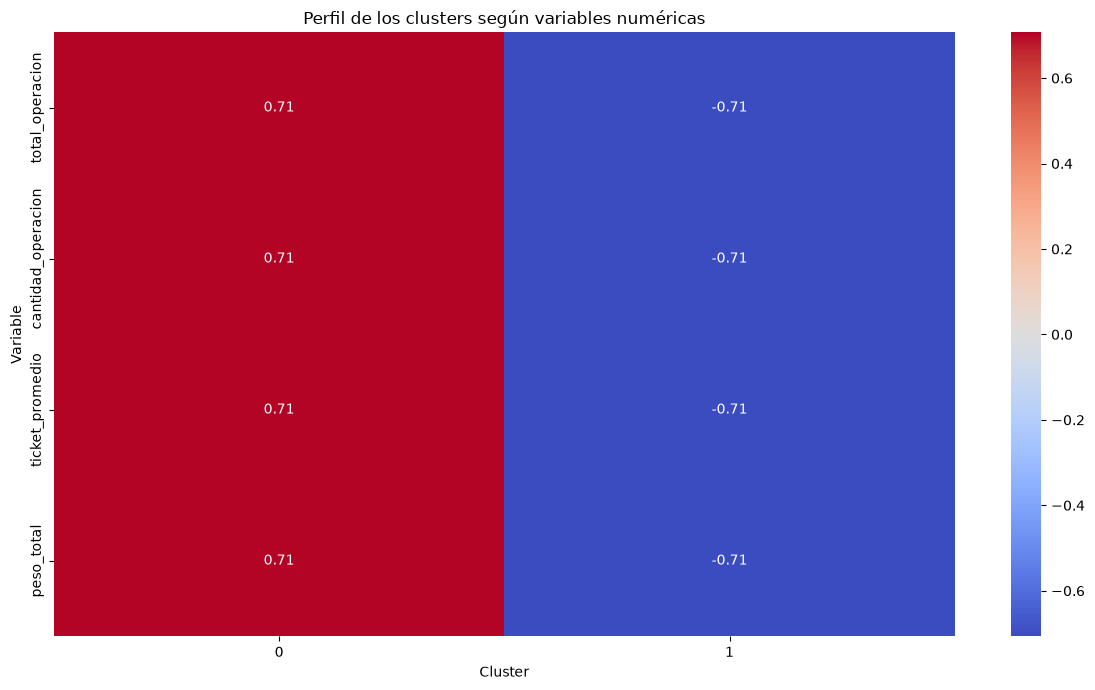

In [20]:
cluster_medianas = df_import.groupby("cluster")[numeric_cols].median()

cluster_medianas_norm = (
    cluster_medianas - cluster_medianas.mean()
) / cluster_medianas.std()

plt.figure(figsize=(12, 7))

sns.heatmap(
    cluster_medianas_norm.T,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.xlabel("Cluster")
plt.ylabel("Variable")
plt.title("Perfil de los clusters según variables numéricas")
plt.tight_layout()
plt.show()

### 6.4 Observación

Con k=2, el modelo separa un grupo de **operaciones grandes** de uno de **operaciones pequeñas** — una distinción válida y muy estable en validación cruzada (media 0,2353, desviación estándar 0,0009), pero demasiado agregada para ser útil como segmentación de negocio.

Aunque k=3 tiene el segundo mejor silhouette, se optó por explorar directamente **k=5** en busca de un perfil con mayor valor interpretativo, aceptando la pérdida adicional de separación a cambio de granularidad.

## 7. Modelo B — k=5 (mayor granularidad)

Se repite el mismo proceso de validación cruzada y ajuste del modelo, ahora fijando k=5, para evaluar si una segmentación más fina resulta en clusters balanceados y con un perfil de negocio distinguible — no solo en un score más alto.

In [21]:
k=5

### 7.1 Validación cruzada

In [22]:
from sklearn.model_selection import KFold

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

#k = 3

scores = []

X = df_import[numeric_cols + categorical_cols]

for train_idx, val_idx in kf.split(X):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    X_train_transformed = preprocessor.fit_transform(X_train)
    X_val_transformed = preprocessor.transform(X_val)

    kmeans = MiniBatchKMeans(
        n_clusters=k,
        random_state=42,
        batch_size=1024,
        n_init=3,
        max_iter=50
    )

    kmeans.fit(X_train_transformed)

    val_labels = kmeans.predict(X_val_transformed)

    # Solo una muestra para calcular silhouette
    sample_size = min(10000, X_val_transformed.shape[0])

    rng = np.random.RandomState(42)
    indices = rng.choice(
        X_val_transformed.shape[0],
        size=sample_size,
        replace=False
    )

    score = silhouette_score(
        X_val_transformed[indices],
        val_labels[indices]
    )

    scores.append(score)

    print(f"Fold terminado: silhouette={score:.4f}")

print("\nSilhouette por fold:")
print(scores)

print("\nMedia:")
print(np.mean(scores))

print("\nDesviación estándar:")
print(np.std(scores))

Fold terminado: silhouette=0.1318
Fold terminado: silhouette=0.1187
Fold terminado: silhouette=0.1436
Fold terminado: silhouette=0.1493
Fold terminado: silhouette=0.1371

Silhouette por fold:
[0.1317673327592316, 0.11868524612878369, 0.14360683648049108, 0.1492952598994961, 0.13706516840912839]

Media:
0.1360839687354262

Desviación estándar:
0.010520868791360464


In [23]:
resultados_cv = pd.DataFrame({
    "fold": range(1, len(scores) + 1),
    "silhouette": scores
})

resultados_cv.loc["media"] = ["media", np.mean(scores)]
resultados_cv.loc["std"] = ["std", np.std(scores)]

resultados_cv

,fold,silhouette
0,1,0.131767
1,2,0.118685
2,3,0.143607
3,4,0.149295
4,5,0.137065
media,media,0.136084
std,std,0.010521


### 7.2 Entrenamiento y perfil de los clusters

In [24]:
pipeline.set_params(
    kmeans__n_clusters=k
)

pipeline.fit(
    df_import[numeric_cols + categorical_cols]
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('kmeans', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['total_operacion','cantidad_operacion','ticket_promedio',..., 'rubro_empresa','pais','via_transporte']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automati

In [25]:
df_import["cluster"] = pipeline.predict(
    df_import[numeric_cols + categorical_cols]
)

In [26]:
df_import["cluster"].value_counts().sort_index()

cluster
0    297787
1    236686
2    389193
3    249123
4    399233
Name: count, dtype: int64

In [27]:
pd.options.display.float_format = '{:,.2f}'.format

df_import.groupby("cluster")[numeric_cols].mean().T

cluster,0,1,2,3,4
total_operacion,"19,372.64","895,663.47","318,815.23",757.85,"8,524.41"
cantidad_operacion,3.58,42.29,2.89,1.46,2.72
ticket_promedio,"8,350.64","27,594.27","126,666.52",598.99,"3,868.76"
peso_total,"1,123.98","1,118,910.40","449,372.56","1,219.35","15,737.61"


In [28]:
pd.options.display.float_format = '{:,.2f}'.format

df_import.groupby("cluster")[numeric_cols].median().T

cluster,0,1,2,3,4
total_operacion,"9,777.00","174,541.18","77,440.00",611.90,"5,781.03"
cantidad_operacion,2.00,19.00,2.00,1.00,2.00
ticket_promedio,"3,995.42","8,335.92","36,349.73",483.66,"2,652.82"
peso_total,409.00,"168,160.02","30,048.50",128.00,"5,786.00"


### 7.3 Visualización del perfil (radar)

Comparación de la posición relativa de cada cluster en las cuatro variables numéricas (normalizadas 0–1 entre clusters, no en términos absolutos).

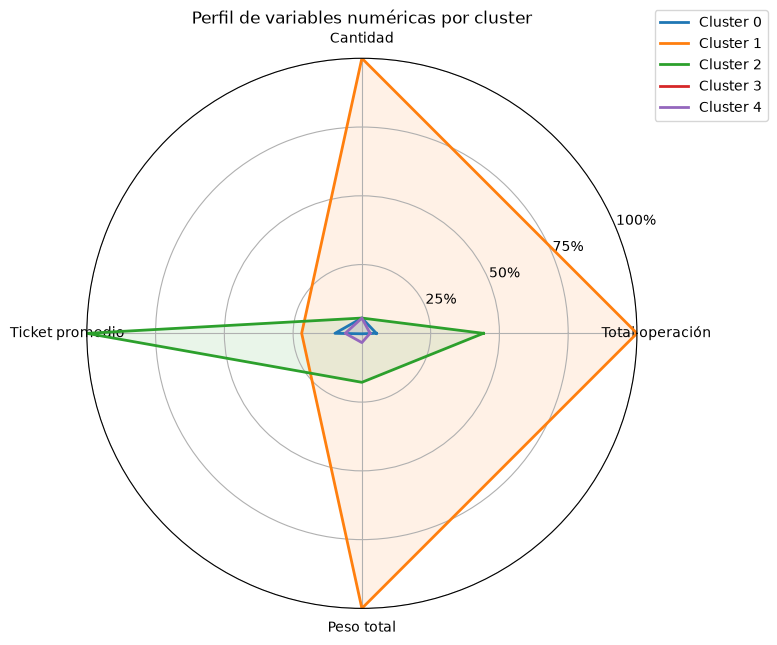

In [29]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt

# Variables que queremos comparar
radar_cols = [
    "total_operacion",
    "cantidad_operacion",
    "ticket_promedio",
    "peso_total"
]

# Mediana por cluster
cluster_stats = (
    df_import
    .groupby("cluster")[radar_cols]
    .median()
)

# Normalización 0-1 entre clusters
scaler = MinMaxScaler()

cluster_norm = pd.DataFrame(
    scaler.fit_transform(cluster_stats),
    columns=radar_cols,
    index=cluster_stats.index
)

# Ángulos del radar
labels = [
    "Total operación",
    "Cantidad",
    "Ticket promedio",
    "Peso total"
]

angles = np.linspace(
    0,
    2 * np.pi,
    len(labels),
    endpoint=False
).tolist()

angles += angles[:1]

# Gráfico
fig, ax = plt.subplots(
    figsize=(8, 8),
    subplot_kw=dict(polar=True)
)

for cluster in cluster_norm.index:

    values = cluster_norm.loc[cluster].tolist()
    values += values[:1]

    ax.plot(
        angles,
        values,
        linewidth=2,
        label=f"Cluster {cluster}"
    )

    ax.fill(
        angles,
        values,
        alpha=0.10
    )

# Ejes
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

ax.set_ylim(0, 1)

ax.set_yticks([0.25, 0.50, 0.75, 1.00])
ax.set_yticklabels(["25%", "50%", "75%", "100%"])

ax.set_title(
    "Perfil de variables numéricas por cluster",
    pad=25
)

ax.legend(
    loc="upper right",
    bbox_to_anchor=(1.25, 1.10)
)

plt.tight_layout()
plt.show()

### 7.4 Composición por rubro de empresa

In [30]:
rubro_cluster = pd.crosstab(
    df_import["cluster"],
    df_import["rubro_empresa"],
    normalize="index"
) * 100

**Distribución completa de rubros dentro de cada cluster:**

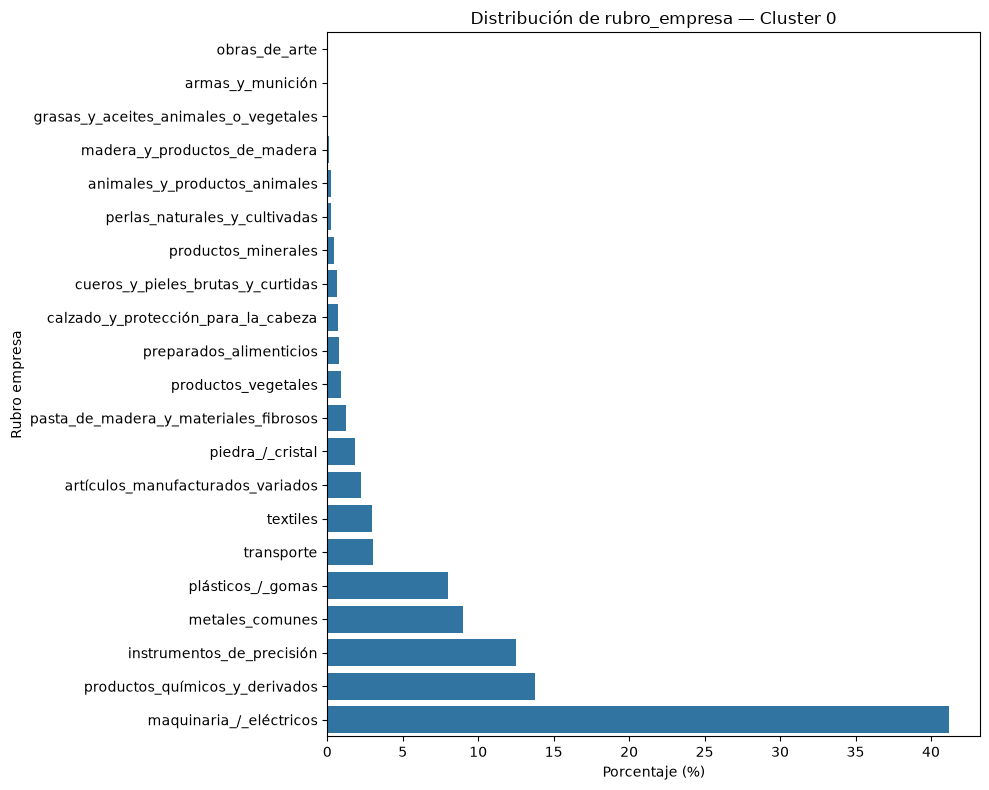

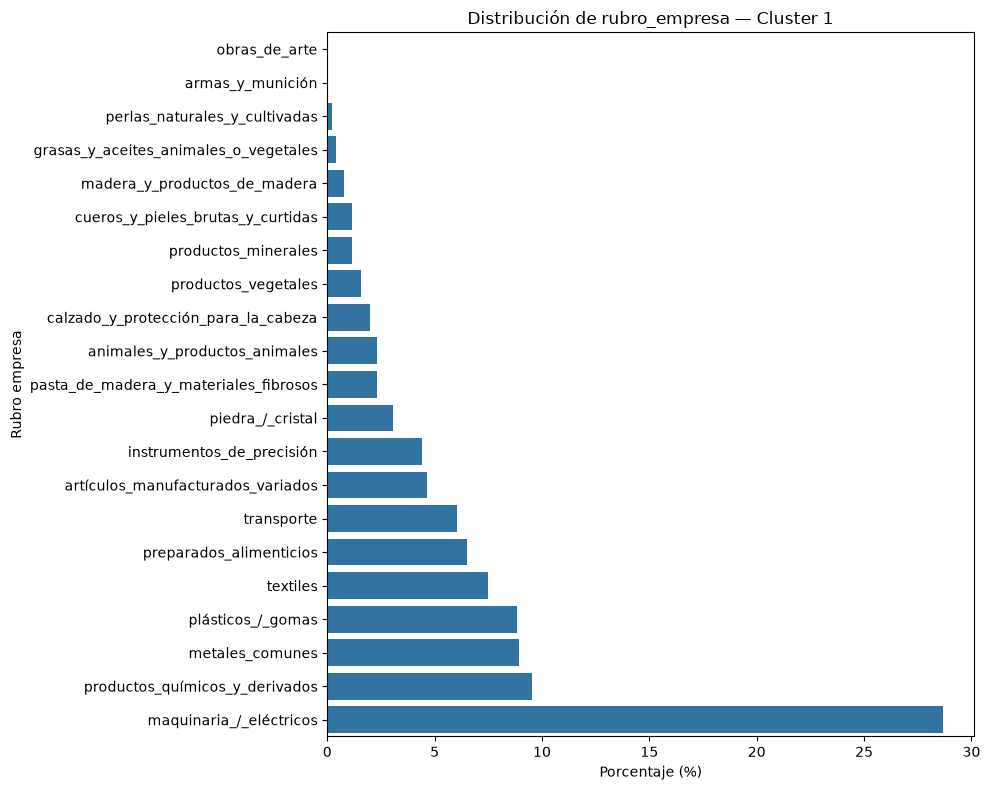

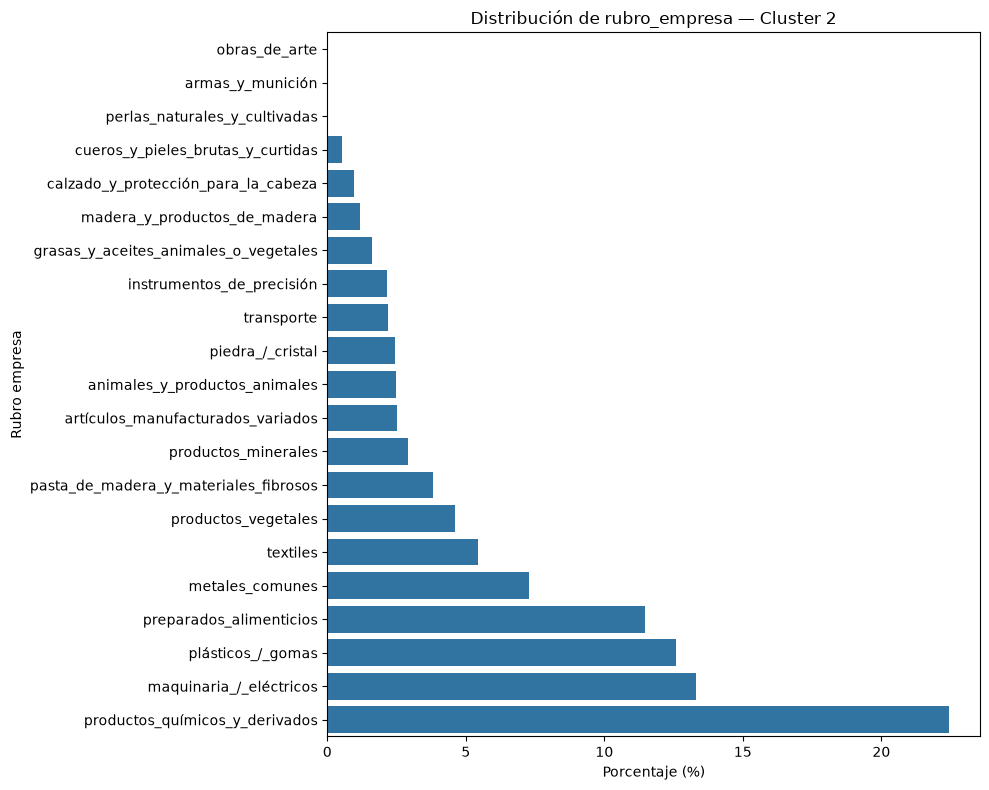

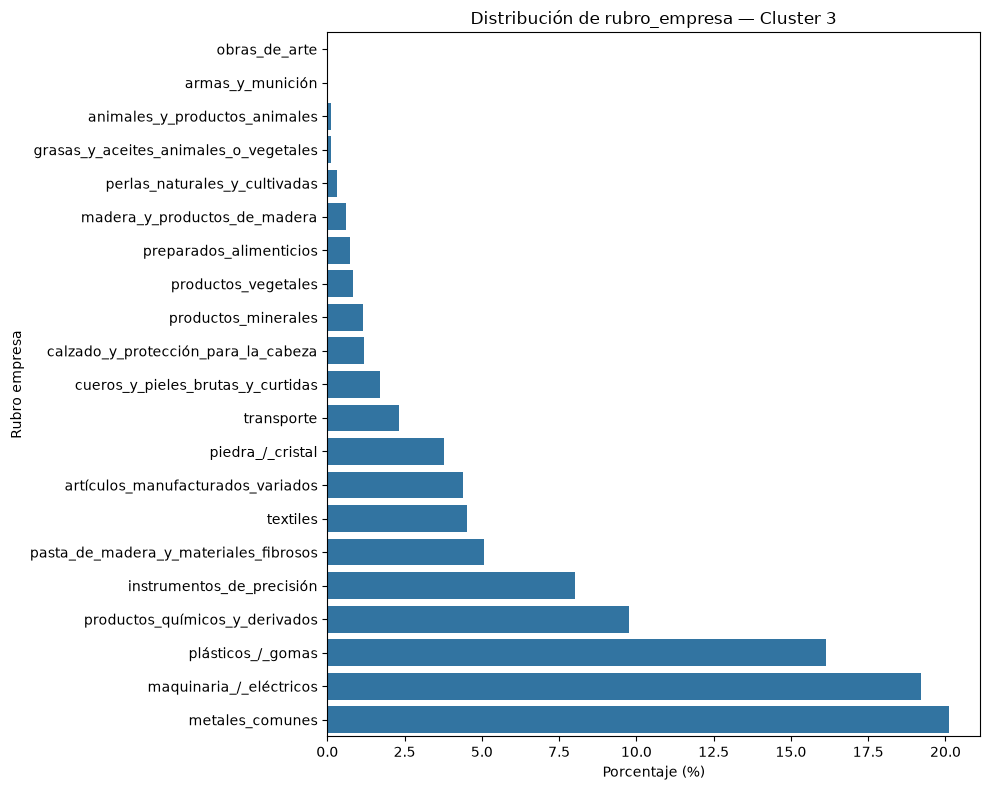

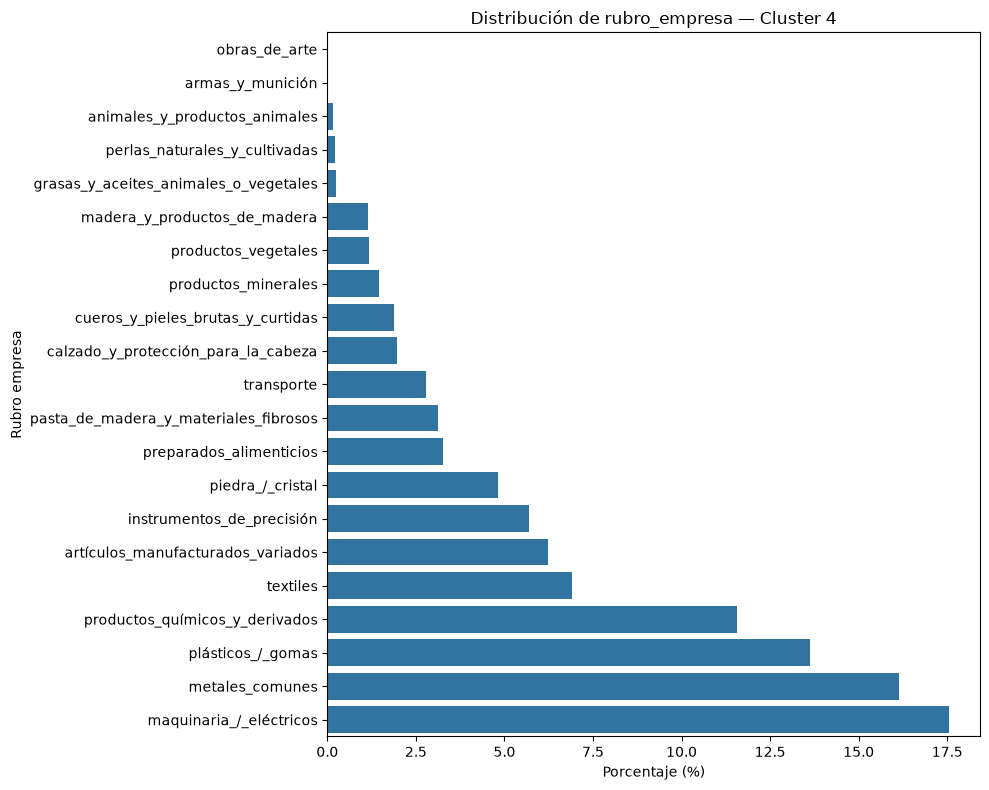

In [31]:
for cluster in sorted(rubro_cluster.index):

    datos = rubro_cluster.loc[cluster].sort_values(ascending=True)

    plt.figure(figsize=(10, 8))

    sns.barplot(
        x=datos.values,
        y=datos.index
    )

    plt.xlabel("Porcentaje (%)")
    plt.ylabel("Rubro empresa")
    plt.title(f"Distribución de rubro_empresa — Cluster {cluster}")

    plt.tight_layout()
    plt.show()

**Comparación entre clusters — top 5 rubros de cada uno:**

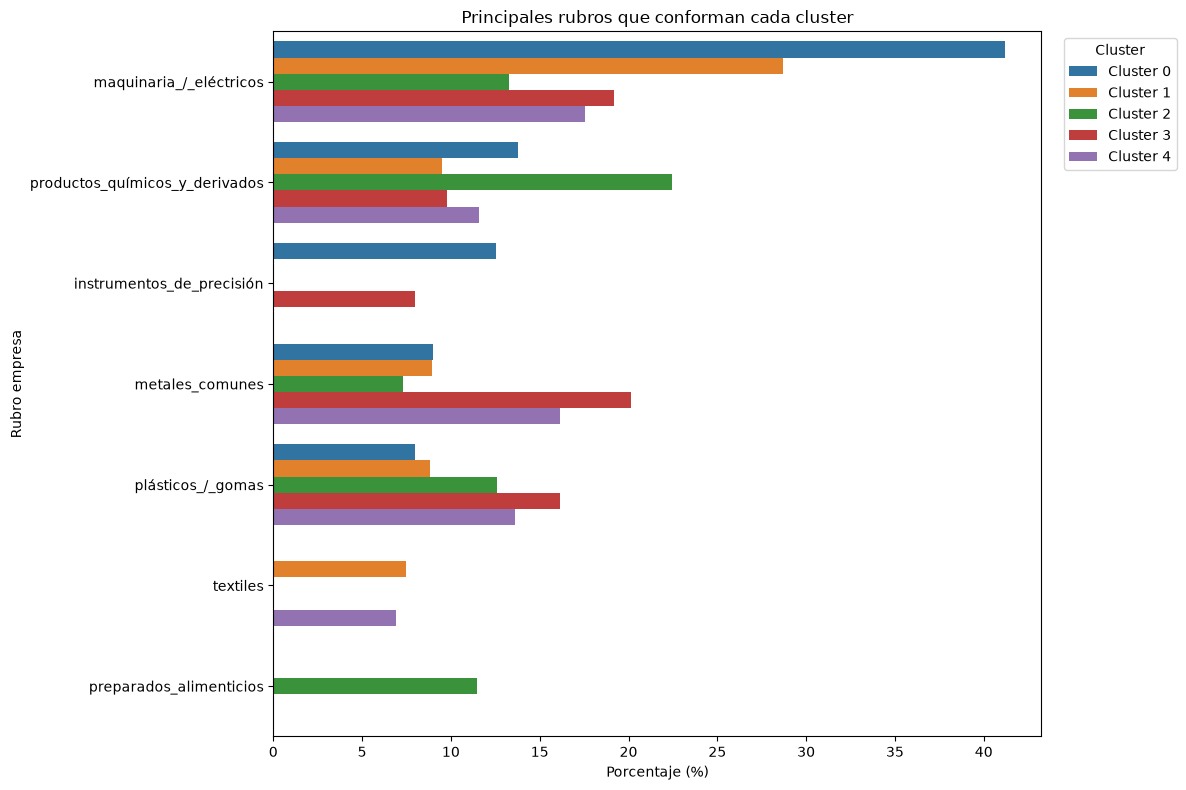

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 5 rubros de cada cluster
top_n = 5

datos = []

for cluster in rubro_cluster.index:

    top = (
        rubro_cluster.loc[cluster]
        .sort_values(ascending=False)
        .head(top_n)
    )

    for rubro, porcentaje in top.items():
        datos.append({
            "cluster": f"Cluster {cluster}",
            "rubro": rubro,
            "porcentaje": porcentaje
        })

df_top_rubros = pd.DataFrame(datos)


# Gráfico
plt.figure(figsize=(12, 8))

sns.barplot(
    data=df_top_rubros,
    x="porcentaje",
    y="rubro",
    hue="cluster"
)

plt.xlabel("Porcentaje (%)")
plt.ylabel("Rubro empresa")
plt.title("Principales rubros que conforman cada cluster")

plt.legend(
    title="Cluster",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### 7.5 Conclusiones — Modelo k=5

**Tamaños de cluster:** el reparto es razonablemente balanceado (entre 15,1% y 25,4% del total cada uno) — no hay clusters residuales de outliers aislados, lo que respalda a k=5 como una segmentación genuina y no un artefacto de forzar demasiadas divisiones.

**Perfil numérico (mediana):**

| Cluster | total_operacion | cantidad_operacion | ticket_promedio | peso_total | Perfil |
|---|---|---|---|---|---|
| 3 | 611,90 | 1 | 483,66 | 128,00 | Micro-operaciones — un solo envío, valor y peso mínimos |
| 4 | 5.781,03 | 2 | 2.652,82 | 5.786,00 | Pequeñas y livianas |
| 0 | 9.777,00 | 2 | 3.995,42 | 409,00 | Pequeñas, muy livianas |
| 2 | 77.440,00 | 2 | 36.349,73 | 30.048,50 | Alto valor unitario, baja frecuencia |
| 1 | 174.541,18 | 19 | 8.335,92 | 168.160,02 | Alto volumen / bulk — la frecuencia más alta por lejos |

La segmentación captura **dos ejes de negocio distintos**: magnitud (cluster 3 < 4 ≈ 0 < 2 < 1) y la relación entre **frecuencia y valor unitario** — el cluster 1 combina mucha frecuencia con ticket moderado, mientras que el cluster 2 tiene el ticket más alto con baja frecuencia. Esta distinción no aparece en absoluto en el modelo k=2.

Cabe destacar que en el cluster 1 la media de `total_operacion` (895.663) es más de 5 veces su mediana (174.541) — señal de que dentro de ese cluster existen operaciones puntuales excepcionalmente grandes que siguen arrastrando el promedio, aun después de la transformación logarítmica aplicada en el preprocesamiento.

**Composición por rubro (según el gráfico comparativo):** los rubros más distintivos por cluster son:
- **Cluster 0** (pequeñas, muy livianas): maquinaria/eléctricos (~41%) e instrumentos de precisión — el único cluster con presencia relevante de este último rubro.
- **Cluster 1** (alto volumen): maquinaria/eléctricos (~29%) y textiles — el único cluster con presencia relevante de textiles.
- **Cluster 2** (alto valor unitario): productos químicos y derivados (~22%) y preparados alimenticios — único cluster con presencia relevante de este rubro.
- **Clusters 3 y 4** (micro/pequeñas): comparten protagonismo en metales comunes y plásticos/gomas — insumos más orientados a manufactura liviana.

> **Nota metodológica:** los porcentajes de esta sección se leyeron del gráfico comparativo (no de una tabla exportada), por lo que son aproximados.

**Conclusión:** k=5 produce clusters balanceados, estables en tamaño y con un perfil de negocio claramente distinguible tanto en magnitud como en composición de rubro — se adopta como la segmentación de referencia del proyecto, con el entendimiento explícito de que sacrifica separación estadística (silhouette 0,1451 vs. 0,2397 en k=2) a cambio de utilidad interpretativa.

## 8. Modelo alternativo — K-Prototypes

K-Means, al depender de distancia euclidiana sobre variables one-hot, trata cada categoría como una dimensión binaria adicional — con muchas columnas categóricas, esto puede diluir el peso relativo de las variables numéricas en el cálculo de distancia.

**K-Prototypes** combina distancia euclidiana para las variables numéricas y distancia de Hamming (ponderada por un parámetro `gamma`) para las categóricas, sin necesidad de one-hot encoding. Se utiliza aquí como **validación independiente**: si arroja resultados similares a K-Means, es evidencia de que el techo de separación observado es una propiedad de los datos, no un artefacto del algoritmo o del preprocesamiento.

In [33]:
import time
import pickle
from kmodes.kprototypes import KPrototypes
from sklearn.preprocessing import OneHotEncoder
import scipy.sparse as sp

In [34]:
# --- Preparar los datos ---
# K-Prototypes no necesita OneHotEncoder para las categóricas,
# pero sí conviene escalar las numéricas para que no dominen la distancia

from sklearn.preprocessing import StandardScaler

df_model = df_import[numeric_cols + categorical_cols].copy()

# Escalar numéricas (mismo criterio que ya usabas: log + scale)
scaler = StandardScaler()
df_model[numeric_cols] = scaler.fit_transform(
    np.log1p(df_model[numeric_cols])
)

# Categóricas deben ir como string (kmodes lo requiere)
for col in categorical_cols:
    df_model[col] = df_model[col].astype(str)

X_mixed = df_model[numeric_cols + categorical_cols].values

# Índices de las columnas categóricas (posición, no nombre)
categorical_idx = [
    df_model.columns.get_loc(col) for col in categorical_cols
]

print("Índices categóricos:", categorical_idx)

Índices categóricos: [4, 5, 6]


In [35]:
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
X_cat_ohe = ohe.fit_transform(df_model[categorical_cols])
X_num = df_model[numeric_cols].values
X_para_silhouette = sp.hstack([X_num, X_cat_ohe]).tocsr()

sample_size = 5000
rng = np.random.RandomState(42)
sil_indices = rng.choice(X_para_silhouette.shape[0], size=sample_size, replace=False)
X_sample_silhouette = X_para_silhouette[sil_indices]

### 8.1 Barrido de k (cost + silhouette)

In [36]:
k_values = range(2, 6)
resultados = []

for k in k_values:
    t0 = time.time()
    print(f"[{time.strftime('%H:%M:%S')}] Empezando k={k}...")

    kproto = KPrototypes(
        n_clusters=k,
        init="Cao",
        n_init=2,
        max_iter=30,
        random_state=42,
        n_jobs=-1
    )

    labels = kproto.fit_predict(X_mixed, categorical=categorical_idx)
    score = silhouette_score(X_sample_silhouette, labels[sil_indices])

    resultado_k = {"k": k, "cost": kproto.cost_, "silhouette": score, "labels": labels}
    resultados.append(resultado_k)

    with open(f"resultado_k{k}.pkl", "wb") as f:
        pickle.dump(resultado_k, f)

    elapsed = time.time() - t0
    print(f"[{time.strftime('%H:%M:%S')}] k={k}: cost={kproto.cost_:.2f}, silhouette={score:.4f} ({elapsed/60:.1f} min)")

[01:05:02] Empezando k=2...
[01:26:47] k=2: cost=5035601.69, silhouette=0.2366 (21.7 min)
[01:26:47] Empezando k=3...
[02:11:16] k=3: cost=4124500.51, silhouette=0.1854 (44.5 min)
[02:11:16] Empezando k=4...
[02:43:38] k=4: cost=3607635.07, silhouette=0.1358 (32.4 min)
[02:43:38] Empezando k=5...
[03:28:26] k=5: cost=3299286.33, silhouette=0.1295 (44.8 min)


### 8.2 Selección del mejor k

In [37]:
import glob

resultados = []
for path in sorted(glob.glob("resultado_k*.pkl")):
    with open(path, "rb") as f:
        resultados.append(pickle.load(f))

resumen = pd.DataFrame([
    {"k": r["k"], "cost": r["cost"], "silhouette": r["silhouette"]}
    for r in resultados
])
resumen.to_csv("resumen_barrido_k.csv", index=False)
print(resumen)

   k          cost  silhouette
0  2  5.035602e+06    0.236557
1  3  4.124501e+06    0.185365
2  4  3.607635e+06    0.135800
3  5  3.299286e+06    0.129502


In [38]:
mejor = resumen.loc[resumen["silhouette"].idxmax()]
k_final = int(mejor["k"])
print(f"Mejor k según silhouette: {k_final} (silhouette={mejor['silhouette']:.4f})")

resultado_final = next(r for r in resultados if r["k"] == k_final)
labels_final = resultado_final["labels"]

df_import["cluster_kproto"] = labels_final
df_import.to_csv("df_import_con_clusters_kproto.csv", index=False)

Mejor k según silhouette: 2 (silhouette=0.2366)


### 8.3 Perfil de los clusters (K-Prototypes, k=2)

In [39]:
perfil_medianas = df_import.groupby("cluster_kproto")[numeric_cols].median()
perfil_medias = df_import.groupby("cluster_kproto")[numeric_cols].mean()
tamanos = df_import["cluster_kproto"].value_counts().sort_index()

perfil_medianas.to_csv("kproto_perfil_medianas.csv")
perfil_medias.to_csv("kproto_perfil_medias.csv")
tamanos.to_csv("kproto_tamanos_cluster.csv")

print(tamanos)
print(perfil_medianas)
print(perfil_medias)

cluster_kproto
0    802146
1    769876
Name: count, dtype: int64
                total_operacion  cantidad_operacion  ticket_promedio  \
cluster_kproto                                                         
0                     70231.835                 5.0       16912.0675   
1                      2721.545                 1.0        1433.9210   

                peso_total  
cluster_kproto              
0                35977.300  
1                  530.145  
                total_operacion  cantidad_operacion  ticket_promedio  \
cluster_kproto                                                         
0                 425665.697320           14.974472     71748.575288   
1                   5178.191993            2.133006      3190.826522   

                   peso_total  
cluster_kproto                 
0               552921.936936  
1                 4053.133994  


In [40]:
for col in categorical_cols:
    crosstab = pd.crosstab(
        df_import["cluster_kproto"],
        df_import[col],
        normalize="index"
    ) * 100
    crosstab.to_csv(f"kproto_distribucion_{col}.csv")

    for cluster in sorted(crosstab.index):
        top5 = crosstab.loc[cluster].sort_values(ascending=False).head(5)
        print(f"Cluster {cluster} - {col}: {dict(top5.round(1))}")

Cluster 0 - rubro_empresa: {'maquinaria_/_eléctricos': np.float64(21.0), 'productos_químicos_y_derivados': np.float64(16.5), 'plásticos_/_gomas': np.float64(11.0), 'metales_comunes': np.float64(8.7), 'preparados_alimenticios': np.float64(8.2)}
Cluster 1 - rubro_empresa: {'maquinaria_/_eléctricos': np.float64(24.9), 'metales_comunes': np.float64(15.7), 'plásticos_/_gomas': np.float64(13.0), 'productos_químicos_y_derivados': np.float64(11.6), 'instrumentos_de_precisión': np.float64(8.4)}
Cluster 0 - pais: {'china': np.float64(25.2), 'u.s.a': np.float64(12.1), 'brasil': np.float64(7.2), 'alemania': np.float64(6.0), 'argentina': np.float64(4.9)}
Cluster 1 - pais: {'china': np.float64(19.1), 'u.s.a': np.float64(16.1), 'alemania': np.float64(10.9), 'italia': np.float64(5.3), 'brasil': np.float64(5.2)}
Cluster 0 - via_transporte: {'maritimo': np.float64(73.4), 'aereo': np.float64(14.8), 'carretero': np.float64(11.8)}
Cluster 1 - via_transporte: {'aereo': np.float64(52.0), 'maritimo': np.float

### 8.4 Conclusiones — K-Prototypes vs. K-Means

K-Prototypes con k=2 obtiene un silhouette de **0,2366**, prácticamente idéntico al 0,2397 de K-Means con el mismo k. Esta coincidencia entre dos algoritmos con mecanismos de distancia distintos **confirma que el techo de separación (~0,24) es una propiedad intrínseca de los datos**, no una limitación del algoritmo elegido ni del one-hot encoding.

El perfil de negocio resultante también es consistente con el modelo K-Means k=2: un cluster de operaciones grandes (mediana total_operacion ≈ 70.232) y uno de operaciones pequeñas (mediana ≈ 2.722). La distribución categórica, esta vez disponible como tabla exacta (no solo gráfico), añade una lectura adicional que K-Means k=2 no había mostrado:

- **Vía de transporte** es el factor más diferenciador entre ambos clusters: el cluster grande usa mayoritariamente transporte **marítimo (73,4%)**, mientras que el cluster pequeño tiene una proporción mucho mayor de **aéreo (52,0%)** — coherente con que los envíos de menor volumen/valor son más viables por vía aérea, y los de mayor escala se concentran en transporte marítimo por eficiencia de costos.
- El rubro predominante (maquinaria/eléctricos) es similar en ambos clusters — el rubro por sí solo no es el principal factor diferenciador en esta segmentación binaria.

## 9. Conclusiones generales del proyecto

**Sobre la selección de k:** tanto K-Means como K-Prototypes coinciden en que k=2 es la configuración con mayor separación estadística (silhouette ~0,24), estable en validación cruzada (desviación estándar <0,001). Sin embargo, k=5 —pese a un silhouette considerablemente menor (0,1451, una caída de ~39% respecto a k=2)— produce clusters balanceados (ninguno por debajo del 15% del total) con una narrativa de negocio mucho más rica: separa las operaciones tanto por **magnitud** como por la relación entre **frecuencia y valor unitario**, algo que la segmentación binaria no puede capturar.

**Recomendación:** la elección entre k=2 y k=5 depende del uso previsto:
- Para un filtro simple o un dashboard de alto nivel ("grande vs. chico"), **k=2** es suficiente y estadísticamente más sólido.
- Para definir estrategias comerciales diferenciadas o entender la composición del negocio, **k=5** ofrece una segmentación considerablemente más accionable, con un costo de separación moderado y justificado.

**Sobre la calidad general del clustering:** ningún modelo probado —bajo ninguna configuración de k, ni con K-Means ni con K-Prototypes— superó un silhouette de 0,27. Esto sugiere que la estructura subyacente de las operaciones de importación es más un **espectro continuo de magnitud** que un conjunto de grupos naturalmente discretos. Es un hallazgo legítimo del análisis, no una falla del proceso de modelado.

**Interpretación de negocio (hipótesis, no verificada directamente en los datos):** dado que Chile no es un productor relevante de bienes de capital ni tecnología, es razonable interpretar que gran parte de las operaciones de importación —particularmente los clusters asociados a maquinaria, eléctricos e instrumentos de precisión— corresponden a la adquisición de equipamiento que el país no fabrica domésticamente. Esta lectura es consistente con los datos observados, pero no está confirmada por una variable del dataset que identifique explícitamente el destino o uso final de cada operación.

## 10. Limitaciones y próximos pasos

- **Sesgo residual:** aunque se aplicó `log1p` antes de estandarizar, la brecha entre media y mediana dentro de algunos clusters (especialmente el cluster 1 en el modelo k=5) sugiere que persisten operaciones excepcionalmente grandes dentro de un mismo grupo. Un próximo paso razonable es tratar el percentil 99+ como un segmento aparte ("operaciones excepcionales"), en vez de forzarlo a convivir con el resto de su cluster.
- **Composición por rubro solo aproximada para k=5:** los porcentajes de rubro reportados en la sección 7.5 se leyeron del gráfico comparativo, no de una tabla exportada como en la sección de K-Prototypes. Exportar el crosstab completo (`rubro_cluster`) como tabla facilitaría un reporting más preciso.
- **Sin variable de commodity específico:** el dataset no identifica el producto exacto (ej. cobre, celulosa, litio), por lo que cualquier hipótesis sectorial más allá de `rubro_empresa` requeriría cruzar con la descripción arancelaria completa o con código de partida.
- **Ponderación no explorada en K-Prototypes:** no se ajustó manualmente el parámetro `gamma` (peso relativo entre distancia numérica y categórica) — usar el valor automático de la librería es razonable como punto de partida, pero probar distintos valores podría mejorar el balance del modelo.
- **Validación adicional:** contrastar con un tercer enfoque (por ejemplo, Gaussian Mixture Models, que no asume clusters esféricos) reforzaría o cuestionaría la conclusión de que el techo de separación (~0,24) es intrínseco a los datos.